In [27]:
import tensorflow as tf
import keras
import glob
import os

Check current runtime

In [28]:
print("Tensorflow version: ",tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices('GPU')) # check for GPU

Tensorflow version:  2.19.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Download & un the data

In [29]:
def get_data_extract():
  if "dataset" in os.listdir():
    print("Dataset already exists")
  else:
    print("Downloading the data...")
    !wget -O food-data.zip https://www.kaggle.com/api/v1/datasets/download/trolukovich/food11-image-dataset
    print("Dataset downloaded!")
    print("Extracting data..")
    !mkdir dataset
    !unzip -q food-data.zip -d dataset
    print("Extraction done!")

get_data_extract()

Dataset already exists


# Dataset

Create Dataset from list of path

In [30]:
path = glob.glob("dataset/*/*/*.jpg")
label = [i.split(".")[0].split("/")[-2] for i in path]

Image augmentation

In [31]:
image_width, image_height = 224,224

aug = keras.Sequential([
    keras.layers.Resizing(image_width, image_height),
])

Dataloader

In [32]:
def load_image(path, label, aug):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    # image augmentation
    image = aug(image)
    return image, label

In [33]:
ds = tf.data.Dataset.from_tensor_slices((path, label))
ds=ds.shuffle(buffer_size=len(path), reshuffle_each_iteration=False) # disable reshuffle_each_iteration to prevent data leak
ds = ds.map(lambda p, l: load_image(p, l, aug), num_parallel_calls=tf.data.AUTOTUNE)

Display Sample from our custom dataset

In [34]:
print("Sample from the dataset:",next(iter(ds))[1])

Sample from the dataset: tf.Tensor(b'Soup', shape=(), dtype=string)


In [10]:
!pip install -q mlflow dagshub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 87.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Model

In [35]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import mlflow
import mlflow.tensorflow
import dagshub

In [36]:

# BONUS: DagsHub + MLflow setup


USE_MLFLOW_DAGSHUB = False
DAGSHUB_USER = "YOUR_DAGSHUB_USERNAME"
DAGSHUB_REPO = "efficientnet-transfer-learning"

if USE_MLFLOW_DAGSHUB:
    dagshub.init(
        repo_owner=DAGSHUB_USER,
        repo_name=DAGSHUB_REPO,
        mlflow=True
    )
    mlflow.set_experiment("EfficientNet_TransferLearning")
else:
    mlflow.set_tracking_uri("file:./mlruns")
    mlflow.set_experiment("EfficientNet_TransferLearning_Local")

mlflow.tensorflow.autolog()

In [37]:

# Prepare labels

class_names = sorted(list(set(label)))
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

label_lookup = keras.layers.StringLookup(
    vocabulary=class_names,
    num_oov_indices=0
)

Classes: ['Bread', 'Dairy product', 'Dessert', 'Egg', 'Fried food', 'Meat', 'Noodles-Pasta', 'Rice', 'Seafood', 'Soup', 'Vegetable-Fruit']
Number of classes: 11


In [38]:

# Split dataset: train / val / test

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    path,
    label,
    test_size=0.2,
    stratify=label,
    random_state=42
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(f"Train samples: {len(train_paths)}")
print(f"Val samples:   {len(val_paths)}")
print(f"Test samples:  {len(test_paths)}")

Train samples: 13314
Val samples:   1664
Test samples:  1665


In [39]:
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_and_encode(path, label):
    image, label = load_image(path, label, aug)
    label = label_lookup(label)
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_ds   = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_ds  = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))

train_ds = train_ds.shuffle(len(train_paths), reshuffle_each_iteration=True)
train_ds = train_ds.map(load_and_encode, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

val_ds = val_ds.map(load_and_encode, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.map(load_and_encode, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)


In [40]:


# Callbacks

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),
    keras.callbacks.ModelCheckpoint(
        "best_efficientnet_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [41]:

# Build model helper

def build_model(num_classes):
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(224, 224, 3)
    )

    inputs = keras.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = keras.layers.GlobalAveragePooling2D()(x)
    x = keras.layers.BatchNormalization()(x)
    x = keras.layers.Dropout(0.3)(x)
    outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs)
    return model, base_model


In [42]:

# transfer learning
# freeze all base layers, train classification head only

model, base_model = build_model(num_classes)

base_model.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

with mlflow.start_run(run_name="Feature_Extraction"):
    mlflow.log_param("model_version", "EfficientNetB0")
    mlflow.log_param("approach", "Feature Extraction")
    mlflow.log_param("image_size", "224x224")
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", 10)
    mlflow.log_param("frozen_base", True)

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 11)             │        14,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,782 (15.52 MB)

 Trainable params: 16,651 (65.04 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [43]:
   history_feature = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=callbacks,
        verbose=1
    )



2026/03/16 20:06:46 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID '82c10ba93b4f46d49cbaa409ce24131e', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current tensorflow workflow


Epoch 1/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6762 - loss: 1.0438

833/833 ━━━━━━━━━━━━━━━━━━━━ 114s 76ms/step - accuracy: 0.7655 - loss: 0.7503 - val_accuracy: 0.8876 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 2/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8451 - loss: 0.4959

833/833 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.8464 - loss: 0.4892 - val_accuracy: 0.9062 - val_loss: 0.2912 - learning_rate: 0.0010
Epoch 3/10
830/833 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8578 - loss: 0.4285

833/833 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.8523 - loss: 0.4566 - val_accuracy: 0.9099 - val_loss: 0.2854 - learning_rate: 0.0010
Epoch 4/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 41s 49ms/step - accuracy: 0.8616 - loss: 0.4254 - val_accuracy: 0.9075 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 5/10
830/833 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8732 - loss: 0.3911

833/833 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.8666 - loss: 0.4148 - val_accuracy: 0.9171 - val_loss: 0.2697 - learning_rate: 0.0010
Epoch 6/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.8742 - loss: 0.3980 - val_accuracy: 0.9069 - val_loss: 0.2746 - learning_rate: 0.0010
Epoch 7/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.8728 - loss: 0.4045 - val_accuracy: 0.9062 - val_loss: 0.2972 - learning_rate: 0.0010
Epoch 8/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 40s 48ms/step - accuracy: 0.8865 - loss: 0.3477 - val_accuracy: 0.9123 - val_loss: 0.2720 - learning_rate: 2.0000e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step


2026/03/16 20:14:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [44]:

    feature_test_loss, feature_test_acc = model.evaluate(test_ds, verbose=0)
    mlflow.log_metric("test_loss", feature_test_loss)
    mlflow.log_metric("test_accuracy", feature_test_acc)

model.save("feature_extraction_model.keras")

print("\nFeature Extraction Test Accuracy:", feature_test_acc)



Feature Extraction Test Accuracy: 0.9003003239631653


In [46]:
model.save("feature_extraction_model.keras")

print("\nFeature Extraction Test Accuracy:", feature_test_acc)


# Fine-tuning


base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

mlflow.end_run()

with mlflow.start_run(run_name="Fine_Tuning"):

    history_finetune = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=10,
        callbacks=callbacks,
        verbose=1
    )


Feature Extraction Test Accuracy: 0.9003003239631653


Epoch 1/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6948 - loss: 0.9587

833/833 ━━━━━━━━━━━━━━━━━━━━ 91s 75ms/step - accuracy: 0.7316 - loss: 0.8442 - val_accuracy: 0.8690 - val_loss: 0.4218 - learning_rate: 1.0000e-05
Epoch 2/10
833/833 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7868 - loss: 0.6662

833/833 ━━━━━━━━━━━━━━━━━━━━ 46s 51ms/step - accuracy: 0.7965 - loss: 0.6325 - val_accuracy: 0.8942 - val_loss: 0.3662 - learning_rate: 1.0000e-05
Epoch 3/10
831/833 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8082 - loss: 0.5965

833/833 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.8084 - loss: 0.5901 - val_accuracy: 0.8966 - val_loss: 0.3589 - learning_rate: 2.0000e-06
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


2026/03/16 20:25:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/16 20:25:40 WARNING mlflow.utils.autologging_utils: Encountered unexpected error during tensorflow autologging: 0.2697330713272095 is not in list


In [49]:
    finetune_test_loss, finetune_test_acc = model.evaluate(test_ds, verbose=0)

    mlflow.log_metric("test_loss", finetune_test_loss)
    mlflow.log_metric("test_accuracy", finetune_test_acc)

model.save("fine_tuned_model.keras")

print("\nFine-Tuning Test Accuracy:", finetune_test_acc)


Fine-Tuning Test Accuracy: 0.8480480313301086


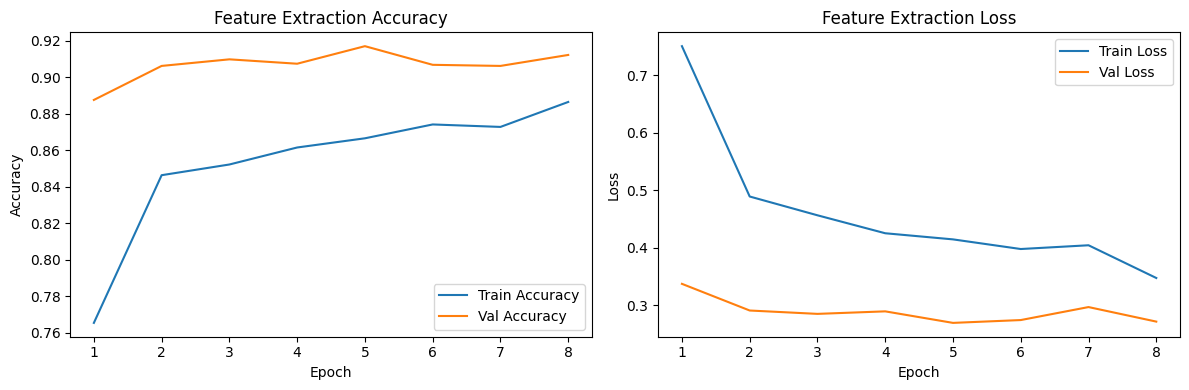

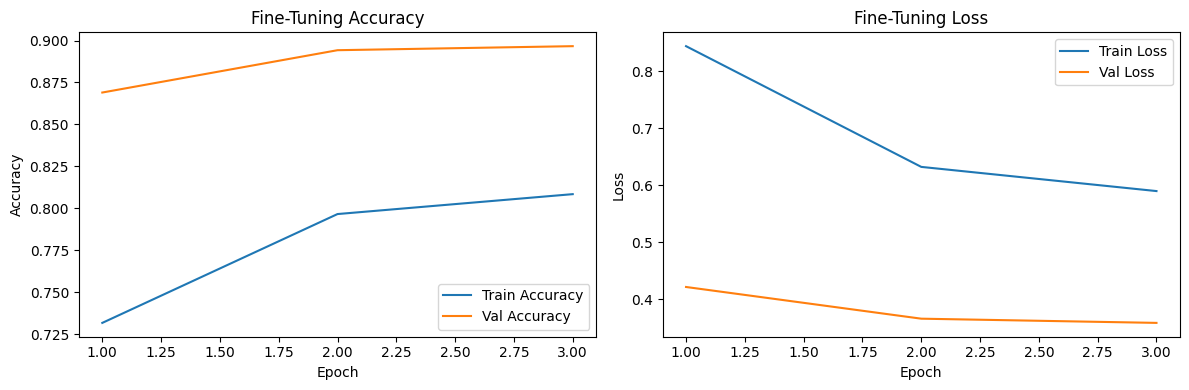

In [50]:
def plot_history(history, title_prefix):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_feature, "Feature Extraction")
plot_history(history_finetune, "Fine-Tuning")

In [51]:
def save_history_plot(history, title_prefix, filename):
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs_range = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label="Train Accuracy")
    plt.plot(epochs_range, val_acc, label="Val Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label="Train Loss")
    plt.plot(epochs_range, val_loss, label="Val Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.close()

save_history_plot(history_feature, "Feature Extraction", "feature_extraction_metrics.png")
save_history_plot(history_finetune, "Fine-Tuning", "fine_tuning_metrics.png")

In [52]:
print("\n========== Final Comparison ==========")
print(f"Feature Extraction Test Accuracy: {feature_test_acc:.4f}")
print(f"Fine-Tuning Test Accuracy:        {finetune_test_acc:.4f}")

if finetune_test_acc > feature_test_acc:
    print("Fine-tuning performed better on the test set.")
elif finetune_test_acc < feature_test_acc:
    print("Feature extraction performed better on the test set.")
else:
    print("Both approaches achieved the same test accuracy.")


========== Final Comparison ==========
Feature Extraction Test Accuracy: 0.9003
Fine-Tuning Test Accuracy:        0.8480
Feature extraction performed better on the test set.


In [53]:
results_summary = {
    "feature_extraction": {
        "test_loss": float(feature_test_loss),
        "test_accuracy": float(feature_test_acc)
    },
    "fine_tuning": {
        "test_loss": float(finetune_test_loss),
        "test_accuracy": float(finetune_test_acc)
    }
}

with open("results_summary.json", "w") as f:
    json.dump(results_summary, f, indent=4)

print("\nSaved:")
print("- feature_extraction_model.keras")
print("- fine_tuned_model.keras")
print("- feature_extraction_metrics.png")
print("- fine_tuning_metrics.png")
print("- results_summary.json")


Saved:
- feature_extraction_model.keras
- fine_tuned_model.keras
- feature_extraction_metrics.png
- fine_tuning_metrics.png
- results_summary.json
